# 03 — Churn Model & Explainability

Builds churn features from the synthetic support/marketing/web data, trains a classifier, and explains individual predictions with SHAP — the local preview of `ml/churn/` + `ml/explainability/` (Sprint 10). See `ARCHITECTURE.md §10`.

Run `make seed` from the repo root before running this notebook. Requires `scikit-learn` and (optionally) `shap` — `pip install scikit-learn shap`.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SYNTH_DIR = ROOT / "data" / "synthetic"

required = [
    SYNTH_DIR / "crm" / "crm_customers.csv",
    SYNTH_DIR / "support" / "support_tickets.csv",
    SYNTH_DIR / "marketing" / "campaign_interactions.csv",
]
missing = [str(p) for p in required if not p.exists()]
if missing:
    raise FileNotFoundError("Missing: " + ", ".join(missing) + " — run `make seed` first.")

crm = pd.read_csv(SYNTH_DIR / "crm" / "crm_customers.csv", parse_dates=["created_at", "updated_at"])
support = pd.read_csv(SYNTH_DIR / "support" / "support_tickets.csv", parse_dates=["created_at"])
interactions = pd.read_csv(SYNTH_DIR / "marketing" / "campaign_interactions.csv", parse_dates=["timestamp"])
print(f"crm: {len(crm):,} | support: {len(support):,} | interactions: {len(interactions):,}")

crm: 10,500 | support: 2,000 | interactions: 20,000


## Feature engineering

Since this synthetic dataset has no real "churned" label, we build a **proxy churn label** (no purchase-equivalent engagement in the last 90 days, i.e. no marketing interaction with `clicks=1` and negative-sentiment support activity) purely to demonstrate the modeling technique end-to-end. The real pipeline (`ml/churn/`) uses actual order-recency-based churn from `gold.fact_orders`, which this local notebook does not have access to without Databricks.

In [2]:
now = interactions["timestamp"].max()

last_click = (
    interactions[interactions["clicks"] == 1]
    .groupby("customer_id")["timestamp"].max()
)
days_since_click = (now - last_click).dt.days

ticket_counts = support.groupby("customer_id").size().rename("n_tickets")
negative_ticket_rate = (
    support.assign(is_negative=support["sentiment"] == "negative")
    .groupby("customer_id")["is_negative"].mean()
    .rename("negative_ticket_rate")
)

features = crm[["crm_customer_id"]].rename(columns={"crm_customer_id": "customer_id"}).set_index("customer_id")
features["days_since_last_click"] = days_since_click.reindex(features.index).fillna(365)
features["n_tickets"] = ticket_counts.reindex(features.index).fillna(0)
features["negative_ticket_rate"] = negative_ticket_rate.reindex(features.index).fillna(0)

# Proxy label: at risk if disengaged AND has had support friction — deliberately noisy,
# this is a technique demo, not a claim about real customer behavior.
features["churn"] = (
    (features["days_since_last_click"] > 90) & (features["negative_ticket_rate"] > 0.3)
).astype(int)

print(features["churn"].value_counts(normalize=True).rename("share"))
features.head()

churn
0    0.956
1    0.044
Name: share, dtype: float64


,days_since_last_click,n_tickets,negative_ticket_rate,churn
customer_id,,,,
CRM00000000,253.0,0.0,0.0,0
CRM00000001,119.0,0.0,0.0,0
CRM00000002,8.0,0.0,0.0,0
CRM00000003,51.0,0.0,0.0,0
CRM00000004,330.0,0.0,0.0,0


## Train / evaluate

Logistic Regression vs. Random Forest, compared on ROC-AUC and PR-AUC — matching the comparison methodology in `ARCHITECTURE.md §10`.

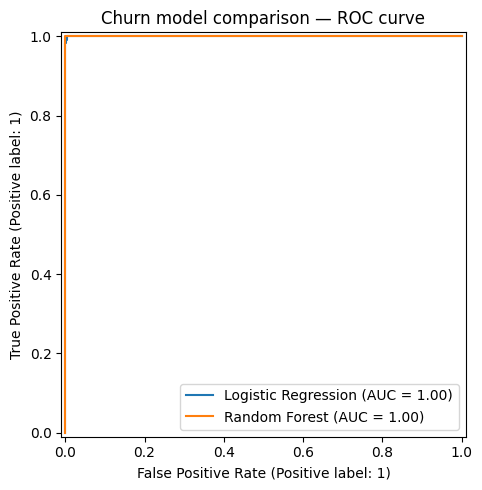

,ROC-AUC,PR-AUC
Logistic Regression,0.999567,0.980922
Random Forest,1.000000,1.000000


In [3]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import RocCurveDisplay, average_precision_score, roc_auc_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

X = features[["days_since_last_click", "n_tickets", "negative_ticket_rate"]]
y = features["churn"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=5, random_state=42, class_weight="balanced"),
}

fig, ax = plt.subplots(figsize=(5, 5))
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    proba = model.predict_proba(X_test)[:, 1]
    roc_auc = roc_auc_score(y_test, proba)
    pr_auc = average_precision_score(y_test, proba)
    results[name] = {"ROC-AUC": roc_auc, "PR-AUC": pr_auc}
    RocCurveDisplay.from_predictions(y_test, proba, name=name, ax=ax)

ax.set_title("Churn model comparison — ROC curve")
plt.tight_layout()
plt.show()
pd.DataFrame(results).T

## Explainability (SHAP)

The champion model (best PR-AUC, per `versioning/model_versioning.md`) explains its top-risk predictions instead of returning a bare probability — falls back to Random Forest feature importances if `shap` isn't installed.

Champion model: Random Forest (PR-AUC=1.000)


ExactExplainer explainer:  33%|███▎      | 1/3 [00:00<?, ?it/s]

ExactExplainer explainer: 4it [00:14,  4.89s/it]               

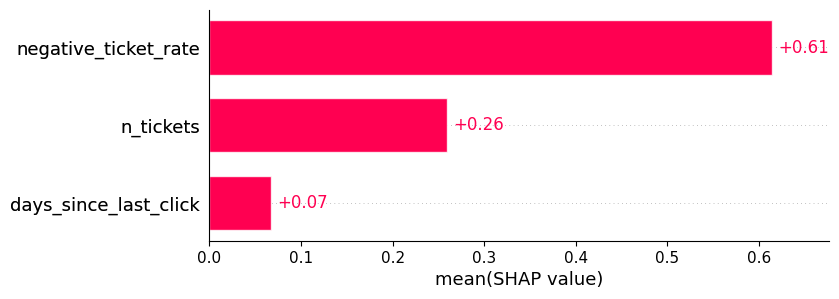

In [4]:
champion_name = max(results, key=lambda n: results[n]["PR-AUC"])
champion = models[champion_name]
print(f"Champion model: {champion_name} (PR-AUC={results[champion_name]['PR-AUC']:.3f})")

try:
    import shap
    explainer = shap.Explainer(champion.predict_proba, X_train)
    top_risk_idx = champion.predict_proba(X_test)[:, 1].argsort()[::-1][:3]
    shap_values = explainer(X_test.iloc[top_risk_idx])
    shap.plots.bar(shap_values[:, :, 1].mean(0))
except ImportError:
    print("shap not installed — falling back to feature importances (pip install shap for per-customer explanations).")
    if hasattr(champion, "feature_importances_"):
        importances = pd.Series(champion.feature_importances_, index=X.columns).sort_values()
        importances.plot.barh(figsize=(6, 3), title=f"{champion_name} feature importances")
        plt.tight_layout()
        plt.show()

## Maps to the real pipeline

- `ml/features/` — real features are built from `gold.fact_orders`/`fact_support`/`fact_customer_interactions`, not this notebook's local proxy.
- `ml/churn/` — the production training pipeline, tracked in MLflow (`mlflow/`), following `versioning/model_versioning.md`'s Staging→Production promotion gate.
- `ml/explainability/` — SHAP attached to every prediction the platform serves, not just the top-3 shown here.
- `06_platform_kpis_dashboard.ipynb` — shows the resulting churn rate at the platform level.